## Breast Cancer Prediction using Supervised Learning Algorithms

### Objective
The goal of this project is to classify tumors as:\

     - Malignant (cancerous)
     - Benign (non-cancerous)
Build a machine learning model that can predict whether a tumor is cancerous based on given features


### Dataset
Dataset is taken from scikit-learn.
Contains features computed from breast mass images

### Steps Involved
     - Data Collection
     - Import Libraries
     - Data Cleaning & Preprocessing
     - Exploratory Data Analysis (EDA)
     - Feature Engineering & Selection
     - Model Building
     - Model Evaluation


## Import Libraries

In [27]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score

### Data Collection
dataset is taken form scikit-learn.
#### Total samples: 569
#### Features: 30 numerical features
#### Target classes:
     - 0 → Malignant
     - 1 → Benign

In [28]:
data = load_breast_cancer()

X = data.data
y = data.target

df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### Data Cleaning & Preprocessing
* Check missing values
* Check data types
* Checking duplicates
* No major cleaning required (dataset is clean)

In [43]:
df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

### Insight
* No missing values → no cleaning needed
* This dataset is already well-prepared

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [45]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [46]:
print(df.duplicated().sum())

0


In [47]:
df.shape

(569, 31)

### Insight:
* Dataset is clean and well-structured
* No missing values
* Suitable for classification tasks

In [48]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Applied feature scaling
#### Why Scaling is Important:
* Features have different ranges
* Algorithms like SVM, KNN depend on distance
#### Scaling ensures:
* Equal importance to all features
* Improved model performance

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

### 1. Logistic Regression
#### How it works:
* Uses a sigmoid function to predict probability
* Converts output into binary classes (0 or 1)
* Finds a linear relationship between features and target
#### Why it is suitable:
*Works well for binary classification problems
* Simple and fast model
* Provides a good baseline performance

In [51]:
lr = LogisticRegression(max_iter=5000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)
print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.9736842105263158


### 2. Decision Tree Classifier
#### How it works:
* Splits data into branches using if-else conditions
* Creates a tree-like structure of decisions
* Chooses best feature splits based on criteria like Gini or Entropy
#### Why it is suitable:
* Easy to understand and interpret
* Can capture non-linear relationships
* Works well without feature scaling

In [52]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)
print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.9298245614035088


### 3. Random Forest Classifier
#### How it works:
* Combines multiple decision trees
* Each tree is trained on random subsets of data
* Final prediction is based on majority voting
#### Why it is suitable:
* Reduces overfitting compared to a single decision tree
* Provides high accuracy and stability
* Handles feature importance effectively

In [53]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.9649122807017544


### 4. Support Vector Machine (SVM)
#### How it works:
* Finds the optimal boundary (hyperplane) that separates classes
* Maximizes the margin between data points of different classes
* Can use kernels to handle complex data
#### Why it is suitable:
* Effective in high-dimensional datasets
* Works well when classes are clearly separable
* Gives strong performance after scaling

In [54]:
svm = SVC()
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

svm_acc = accuracy_score(y_test, svm_pred)
print("SVM Accuracy:", svm_acc)

SVM Accuracy: 0.9736842105263158


### 5. k-Nearest Neighbors (k-NN)
#### How it works:
* Classifies data based on the nearest neighbors
* Uses distance metrics 
* Assigns the class most common among neighbors
#### Why it is suitable:
* Simple and intuitive algorithm
* No training phase (lazy learner)
* Works well with properly scaled data

In [55]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)

knn_acc = accuracy_score(y_test, knn_pred)
print("KNN Accuracy:", knn_acc)

KNN Accuracy: 0.9473684210526315


### Model Comparison

In [56]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM', 'KNN'],
    'Accuracy': [lr_acc, dt_acc, rf_acc, svm_acc, knn_acc]
})

results.sort_values(by='Accuracy', ascending=False)

,Model,Accuracy
0,Logistic Regression,0.973684
3,SVM,0.973684
2,Random Forest,0.964912
4,KNN,0.947368
1,Decision Tree,0.929825


#### insights
* Random Forest and SVM
   - These models achieved the highest accuracy
   - They generalize better on unseen data
* Decision Tree Classifier
   - these model achieved the lowest accuracy

### Confusion Matrix

A confusion matrix is used to evaluate the performance of a classification model by comparing actual values with predicted values.

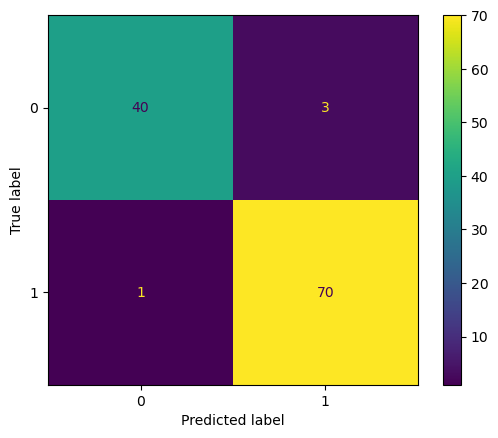

In [57]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, rf_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()

#### It displays four important outcomes:
* True Positive (TP)
   - Model correctly predicts malignant (cancer)
* True Negative (TN)
   - Model correctly predicts benign (non-cancer)
* False Positive (FP)
  - Model predicts cancer, but it is actually not cancer
* False Negative (FN)
   - Model predicts non-cancer, but it is actually cancer